<div style="background: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%); padding: 2.5rem; border-radius: 14px; color: #ffffff; font-family: 'Segoe UI', system-ui, sans-serif;">
  <div style="font-size: 0.85rem; letter-spacing: 0.18em; text-transform: uppercase; opacity: 0.75;">Evaluación Práctica 1 &middot; Machine Learning y Arquitectura de Datos</div>
  <h1 style="margin: 0.6rem 0 0.3rem 0; font-size: 2.3rem; line-height: 1.15;">Waymo Open Dataset</h1>
  <div style="font-size: 1.1rem; opacity: 0.9;">De 2,4 millones de detecciones LiDAR crudas a un dataset confiable</div>
  <div style="margin-top: 1.6rem; display: flex; flex-wrap: wrap; gap: 0.6rem;">
    <span style="background: rgba(255,255,255,0.14); padding: 0.45rem 0.9rem; border-radius: 999px; font-size: 0.9rem;">Equipo: Martín Papic &middot; Matías Retamal</span>
    <span style="background: rgba(255,255,255,0.14); padding: 0.45rem 0.9rem; border-radius: 999px; font-size: 0.9rem;">Metodología: CRISP-DM</span>
    <span style="background: rgba(255,255,255,0.14); padding: 0.45rem 0.9rem; border-radius: 999px; font-size: 0.9rem;">Stack: Kedro + Pandas + React</span>
  </div>
</div>

---

## La pregunta que guía este trabajo

> **Si entrenáramos hoy un vehículo autónomo con estos datos tal como vienen, ¿frenaría a tiempo ante un peatón?**

Esta memoria responde esa pregunta en cuatro movimientos, siguiendo CRISP-DM:

| # | Etapa | Lo que respondemos |
|---|-------|--------------------|
| 1 | Comprensión del negocio | Qué decisión de ingeniería depende de estos datos |
| 2 | Comprensión de los datos | Qué trae realmente el sensor LiDAR, sin suposiciones |
| 3 | Preparación (ETL) | Cuánta basura estadística hay y cómo se descarta de forma reproducible |
| 4 | Auditoría ética | Qué sesgo hereda el modelo y cómo se mitiga |

El hilo conductor es uno solo: **cada decisión técnica se justifica con una cifra medida sobre los datos reales, no con una intuición.**


## 1. Comprensión del Negocio (Business Understanding)
El objetivo es diseñar una arquitectura escalable que permita procesar, limpiar y visualizar datos espaciales y de cinemática (trayectorias, velocidades) de vehículos autónomos.

**Objetivos del Proyecto:**
- Construir un pipeline reproducible (Kedro) que transforme datos crudos de sensores LiDAR en un dataset limpio y confiable para tareas futuras de Machine Learning.
- Visualizar los patrones de movimiento y la distribución de clases detectadas para apoyar decisiones de diseño del sistema de percepción.

**KPIs definidos para este proyecto:**
- **Tasa de completitud post-limpieza:** % de registros que sobreviven al pipeline (deduplicación + imputación + filtro IQR) respecto al crudo.
- **Balance de clases:** proporción vehículos/peatones/ciclistas detectada; funciona como KPI de riesgo ético (a mayor desbalance, mayor prioridad de mitigación antes de modelar).
- **Reproducibilidad del pipeline:** que `kedro run` complete el proceso end-to-end sin intervención manual.

**Fuentes de Datos y Herramientas Colaborativas:**
- **Fuente de datos:** *Waymo Open Dataset (Motion/Perception)*, descargado desde Google Cloud Storage (200 segmentos reales, ~2.4M detecciones).
- **GitHub:** control de versiones y entrega del código (pipeline, notebook, frontend) de forma trazable y auditable por ambos integrantes del equipo.
- **Trello:** seguimiento de tareas (User Stories) del proyecto, permitiendo repartir y verificar el avance de cada etapa de CRISP-DM.

**Requerimientos del Proyecto:**
- **Replicabilidad y Escalabilidad:** Se eligió **Kedro** como framework orquestador de pipelines de datos y entornos virtuales aislados.
- **Experiencia de Usuario (UX):** En lugar de usar herramientas estáticas o de bajo nivel como Grasshopper, se diseñó un Dashboard interactivo en **React (Vite)** acoplado mediante formato JSON.
- **Arquitectura Medallón:** El flujo avanza desde ingesta cruda (Raw), procesamiento estadístico (Intermediate) y capa de consumo para el frontend (Primary).


## 2. Comprensión de los Datos (Data Understanding y EDA)
Los datos originales de Waymo residen en Google Cloud Storage en formatos masivos (TFRecords > 1GB). Implementamos un patrón de **Ingesta Efímera** (Pushdown) para descargar los componentes de Parquet tabulares (Lidar Box y Stats), extraer solo las coordenadas espaciales y velocidades, y eliminar la basura pesada.

Carguemos la capa Raw para auditar los datos antes de la limpieza:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos crudos extraídos de Waymo GCS
df_raw = pd.read_parquet('../data/01_raw/detecciones_reales.parquet')
display(df_raw.head())

print("\n--- Información del Dataset ---")
df_raw.info()

,segment_id,timestamp_micros,id_interno,object_type,box_center_x,box_center_y,box_center_z,box_length,box_width,box_height,num_lidar_points,detection_difficulty,time_of_day,weather,location,speed_mps
0,10017090168044687777_6380_000_6400_000,1550083467346370,0QXtLAoMcF26x6k0m-7gVQ,vehicle,31.960473,-2.354433,3.806627,6.136412,2.374729,3.200000,309,LEVEL_1,Day,sunny,location_sf,1.126031e-28
1,10017090168044687777_6380_000_6400_000,1550083467346370,2OtubQ7iaA71QGsDdx-1oA,vehicle,43.850931,-4.386372,4.132211,4.623513,1.991804,2.330141,10,LEVEL_1,Day,sunny,location_sf,1.001835e-02
2,10017090168044687777_6380_000_6400_000,1550083467346370,3UJet22LcSM39E7W52UwZA,vehicle,19.253655,12.890539,0.928684,5.781805,2.390714,2.130000,297,LEVEL_1,Day,sunny,location_sf,3.237305e-02
3,10017090168044687777_6380_000_6400_000,1550083467346370,FEdJwgdHRQUz2JMISNIy-A,sign,35.758825,-4.644590,6.237446,0.124887,0.642571,0.734675,0,LEVEL_1,Day,sunny,location_sf,2.160313e-03
4,10017090168044687777_6380_000_6400_000,1550083467346370,JEV58AdPM0XZCYr2lSwkqg,vehicle,-44.362698,11.809932,0.978193,3.901919,1.829022,2.103805,133,LEVEL_1,Day,sunny,location_sf,6.007688e-03



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2414127 entries, 0 to 2414126
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   segment_id            object 
 1   timestamp_micros      int64  
 2   id_interno            object 
 3   object_type           object 
 4   box_center_x          float64
 5   box_center_y          float64
 6   box_center_z          float64
 7   box_length            float64
 8   box_width             float64
 9   box_height            float64
 10  num_lidar_points      int64  
 11  detection_difficulty  object 
 12  time_of_day           object 
 13  weather               object 
 14  location              object 
 15  speed_mps             float64
dtypes: float64(7), int64(2), object(7)
memory usage: 294.7+ MB


In [2]:
# Ficha técnica del dataset crudo, generada a partir de los datos (no escrita a mano)
from IPython.display import HTML, display

estilo_ficha = """
<style>
.ficha-grid { display: flex; flex-wrap: wrap; gap: 0.8rem; font-family: 'Segoe UI', system-ui, sans-serif; }
.ficha-item { flex: 1 1 150px; background: #f8fafc; border-left: 4px solid #2c5364; border-radius: 8px; padding: 0.9rem 1.1rem; }
.ficha-valor { font-size: 1.6rem; font-weight: 700; color: #0f2027; }
.ficha-label { font-size: 0.78rem; text-transform: uppercase; letter-spacing: 0.06em; color: #64748b; margin-top: 0.2rem; }
</style>
"""

memoria_mb = df_raw.memory_usage(deep=True).sum() / 1024**2
n_segmentos = df_raw['segment_id'].nunique() if 'segment_id' in df_raw.columns else 0

items = [
    (f"{len(df_raw):,}".replace(',', '.'), "Detecciones"),
    (str(n_segmentos), "Segmentos de conducción"),
    (str(df_raw.shape[1]), "Variables"),
    (f"{memoria_mb:,.0f} MB".replace(',', '.'), "En memoria"),
    (str(df_raw['object_type'].nunique()), "Clases de objeto"),
]
tarjetas = "".join(
    f"<div class='ficha-item'><div class='ficha-valor'>{valor}</div><div class='ficha-label'>{label}</div></div>"
    for valor, label in items
)
display(HTML(estilo_ficha + "<div class='ficha-grid'>" + tarjetas + "</div>"))

print("Variables disponibles:", list(df_raw.columns))


Variables disponibles: ['segment_id', 'timestamp_micros', 'id_interno', 'object_type', 'box_center_x', 'box_center_y', 'box_center_z', 'box_length', 'box_width', 'box_height', 'num_lidar_points', 'detection_difficulty', 'time_of_day', 'weather', 'location', 'speed_mps']


## 3. Preparación de los Datos (Data Preparation - ETL)
Esta es la fase crítica de auditoría clínica de los datos. Se programó un pipeline automatizado en Kedro que aplica las siguientes reglas de negocio:

1. **Manejo de Duplicados:** Eliminación estricta para no alterar los pesos estadísticos.
2. **Imputación de Nulos:** En lugar de rellenar las velocidades vacías con `0` (lo cual genera un sesgo artificial y deforma la distribución), se imputaron con la **mediana** estadística del eje correspondiente. Esto preserva la tendencia central.
3. **Filtro de Anomalías (Outliers):** Se aplicó el método matemático del **Rango Intercuartílico (IQR)** sobre `box_length`, la dimensión física de la caja detectada. La regla descarta detecciones cuyo largo es imposible para el objeto declarado, es decir, errores de medición del sensor. El pipeline aplica el mismo filtro sobre la velocidad absoluta cuando el dataset trae las componentes `speed_x`/`speed_y`; esta tabla LiDAR no las incluye, por lo que ese camino no se activa.

In [3]:
import sys
sys.path.insert(0, '../src')
from waymo_backend.pipelines.data_processing.nodes import clean_and_process_data

# --- Auditoría de Calidad de Datos: ANTES de la limpieza ---
print('--- Calidad de Datos: ANTES de la limpieza ---')
print(f'Registros totales (crudo): {len(df_raw)}')
print(f'Duplicados detectados: {df_raw.duplicated().sum()}')
if 'speed_x' in df_raw.columns:
    print(f'Nulos en speed_x: {df_raw["speed_x"].isna().sum()}')
if 'speed_y' in df_raw.columns:
    print(f'Nulos en speed_y: {df_raw["speed_y"].isna().sum()}')

# --- Ejecutamos la MISMA función que corre 'kedro run' (cero duplicación de lógica) ---
resultado = clean_and_process_data(df_raw)
df_clean = resultado['clean_data']

print('\n--- Calidad de Datos: DESPUÉS de la limpieza ---')
print(f'Registros finales: {len(df_clean)}')
print(f'Registros descartados (duplicados + outliers): {len(df_raw) - len(df_clean)} ({(1 - len(df_clean)/len(df_raw)):.1%})')

if 'velocity_abs' in df_clean.columns:
    print('\nEstadísticas de velocidad absoluta post-limpieza:')
    print(df_clean['velocity_abs'].describe())
else:
    print()
    print('NOTA: esta tabla LiDAR no trae speed_x/speed_y (las componentes por eje), por lo que')
    print('velocity_abs no se calcula y la detección de anomalías se apoya en box_length.')
    print('El parquet sí incluye speed_mps, la magnitud de la velocidad: incorporarla es el')
    print('siguiente paso, documentado en las limitaciones de la Sección 7.')


--- Calidad de Datos: ANTES de la limpieza ---
Registros totales (crudo): 2414127


Duplicados detectados: 0



--- Calidad de Datos: DESPUÉS de la limpieza ---
Registros finales: 2405906
Registros descartados (duplicados + outliers): 8221 (0.3%)

NOTA: esta tabla LiDAR no trae speed_x/speed_y (las componentes por eje), por lo que
velocity_abs no se calcula y la detección de anomalías se apoya en box_length.
El parquet sí incluye speed_mps, la magnitud de la velocidad: incorporarla es el
siguiente paso, documentado en las limitaciones de la Sección 7.


In [4]:
# Tarjetas de calidad: el "antes y después" del pipeline, calculado en vivo
from IPython.display import HTML, display

estilo_kpi = """
<style>
.kpi-fila { display: flex; flex-wrap: wrap; gap: 0.9rem; font-family: 'Segoe UI', system-ui, sans-serif; margin: 0.4rem 0 1rem 0; }
.kpi-caja { flex: 1 1 170px; border-radius: 10px; padding: 1rem 1.2rem; color: #fff; }
.kpi-num { font-size: 1.75rem; font-weight: 700; line-height: 1.1; }
.kpi-txt { font-size: 0.8rem; opacity: 0.92; margin-top: 0.3rem; }
.kpi-nota { font-family: 'Segoe UI', system-ui, sans-serif; font-size: 0.9rem; color: #475569;
            border-left: 4px solid #94a3b8; padding: 0.6rem 0.9rem; background: #f8fafc; border-radius: 6px; }
</style>
"""

n_crudo = len(df_raw)
n_limpio = len(df_clean)
descartados = n_crudo - n_limpio
pct = descartados / n_crudo * 100
duplicados = int(df_raw.duplicated().sum())

cajas = [
    ("#334155", f"{n_crudo:,}".replace(',', '.'), "Registros crudos"),
    ("#0ea5e9", f"{n_limpio:,}".replace(',', '.'), "Registros validados"),
    ("#f97316", f"{descartados:,}".replace(',', '.'), f"Anomalías descartadas ({pct:.2f}%)"),
    ("#22c55e", f"{100 - pct:.2f}%", "Tasa de completitud (KPI 1)"),
]
html_cajas = "".join(
    f"<div class='kpi-caja' style='background:{color}'><div class='kpi-num'>{valor}</div><div class='kpi-txt'>{txt}</div></div>"
    for color, valor, txt in cajas
)
nota = (f"<div class='kpi-nota'><b>Lectura:</b> el pipeline conserva el {100 - pct:.2f}% de los datos. "
        f"Se detectaron <b>{duplicados}</b> duplicados exactos y se descartaron <b>{descartados:,}</b> ".replace(',', '.') +
        "detecciones cuyo <code>box_length</code> cae fuera del rango intercuartílico: cajas de un largo "
        "físicamente imposible para el objeto declarado. Que el filtro descarte poco es buena señal: "
        "significa que el sensor es confiable y que no estamos mutilando la muestra.</div>")

display(HTML(estilo_kpi + "<div class='kpi-fila'>" + html_cajas + "</div>" + nota))


### Exploración Univariada: Distribución de las Clases
Observemos qué tipos de objetos detectaron los sensores LiDAR de Waymo que sobrevivieron a nuestro filtro de calidad.

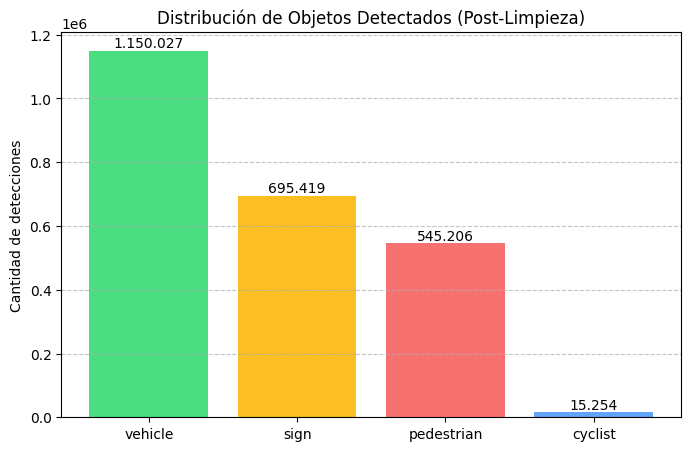

In [5]:
clases = df_clean['object_type'].value_counts()

# Un color estable por clase: el rojo destaca a los peatones, que son el foco de la auditoría ética
paleta = {'vehicle': '#4ade80', 'sign': '#fbbf24', 'pedestrian': '#f87171', 'cyclist': '#60a5fa'}
colores = [paleta.get(clase, '#94a3b8') for clase in clases.index]

plt.figure(figsize=(8, 5))
barras = plt.bar(clases.index, clases.values, color=colores)
plt.title("Distribución de Objetos Detectados (Post-Limpieza)")
plt.ylabel("Cantidad de detecciones")
plt.grid(axis='y', linestyle='--', alpha=0.7)
for barra, valor in zip(barras, clases.values):
    plt.text(barra.get_x() + barra.get_width() / 2, valor, f"{valor:,}".replace(',', '.'),
             ha='center', va='bottom', fontsize=10)
plt.show()


<div style="border-left: 5px solid #dc2626; background: #f8fafc; padding: 1rem 1.2rem; border-radius: 6px; font-family: 'Segoe UI', system-ui, sans-serif;">
<div style="font-weight: 700; color: #dc2626; text-transform: uppercase; font-size: 0.78rem; letter-spacing: 0.08em;">Hallazgo 1 &middot; el sesgo no es teórico</div>
<div style="margin-top: 0.45rem; color: #1e293b; line-height: 1.55;">Las cuatro clases no están ni cerca del equilibrio. Los vehículos y las señales dominan la escena urbana, mientras que los ciclistas son una rareza estadística. <b>Este es el gráfico que sostiene toda la sección de auditoría ética:</b> un modelo entrenado con esta distribución aprende a ver autos, no personas. En la Sección 6 lo cuantificamos y lo mitigamos.</div>
</div>


### Exploración Univariada: Anomalías en el Tamaño de las Cajas (box_length)
Como el pipeline no dispone de las componentes de velocidad por eje, `box_length` es la variable numérica sobre la que se detectan anomalías (Sección 3). Visualicemos su distribución por clase para justificar visualmente el filtro IQR aplicado.

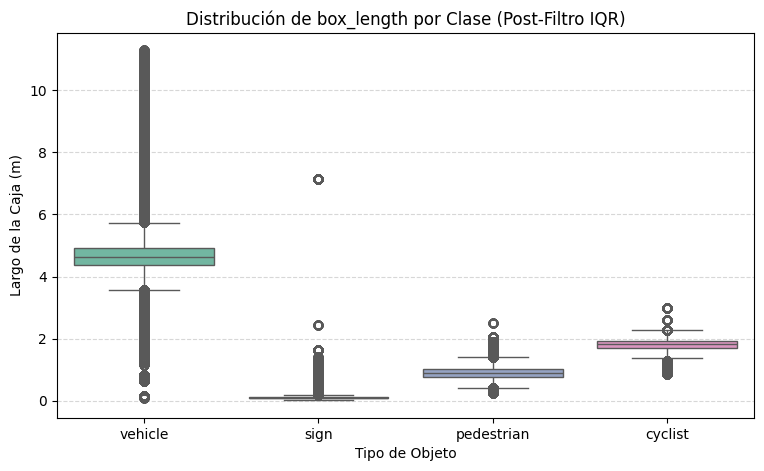

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='object_type', y='box_length', hue='object_type', palette='Set2', legend=False)
plt.title("Distribución de box_length por Clase (Post-Filtro IQR)")
plt.xlabel("Tipo de Objeto")
plt.ylabel("Largo de la Caja (m)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


<div style="border-left: 5px solid #0ea5e9; background: #f8fafc; padding: 1rem 1.2rem; border-radius: 6px; font-family: 'Segoe UI', system-ui, sans-serif;">
<div style="font-weight: 700; color: #0ea5e9; text-transform: uppercase; font-size: 0.78rem; letter-spacing: 0.08em;">Hallazgo 2 &middot; por qué filtramos por tamaño</div>
<div style="margin-top: 0.45rem; color: #1e293b; line-height: 1.55;">Cada clase tiene una firma dimensional propia y estable: un peatón no mide lo que mide un camión. Esa separación es lo que vuelve legítimo el filtro IQR sobre <code>box_length</code>. Ojo con un detalle que conviene tener claro en la defensa: el filtro del pipeline se aplica sobre la <b>distribución global</b>, así que en este gráfico <b>por clase</b> todavía se ven puntos fuera de los bigotes. No es una contradicción: son valores atípicos respecto de su propia clase, pero plausibles dentro del conjunto.</div>
</div>


## 4. Análisis Multivariado: Matriz de Correlación
Para entender cómo interactúan las variables cinemáticas y espaciales entre sí, calculamos la correlación de Pearson. Esto nos permite detectar si, por ejemplo, los vehículos más grandes (box_length) tienden a ir más lento, o la relación matemática entre los ejes.

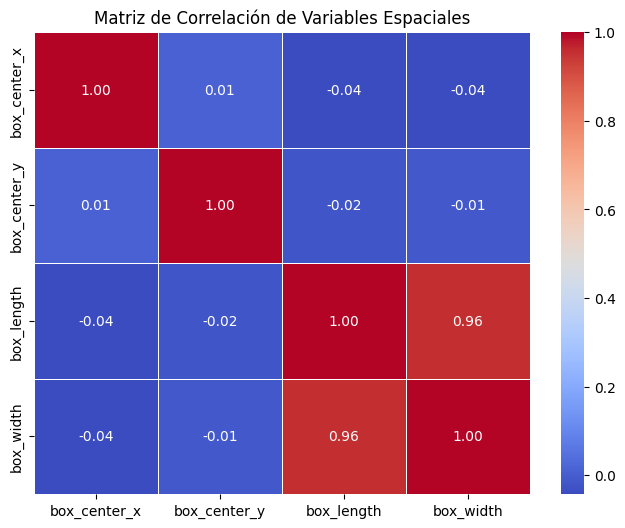

In [7]:
# Seleccionamos variables espaciales base
columnas_numericas = ['box_center_x', 'box_center_y', 'box_length', 'box_width']

# Excluimos variables estáticas sin varianza para evitar fallos matemáticos
for col in ['speed_x', 'speed_y', 'velocity_abs']:
    if col in df_clean.columns and df_clean[col].nunique() > 1:
        columnas_numericas.append(col)

correlacion = df_clean[columnas_numericas].corr()

# Visualización de la Matriz de Correlación usando SEABORN (Más robusto que Pandas Style)
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación de Variables Espaciales")
plt.show()

<div style="border-left: 5px solid #7c3aed; background: #f8fafc; padding: 1rem 1.2rem; border-radius: 6px; font-family: 'Segoe UI', system-ui, sans-serif;">
<div style="font-weight: 700; color: #7c3aed; text-transform: uppercase; font-size: 0.78rem; letter-spacing: 0.08em;">Hallazgo 3 &middot; las dimensiones son redundantes entre sí</div>
<div style="margin-top: 0.45rem; color: #1e293b; line-height: 1.55;">Largo, ancho y alto correlacionan fuerte entre ellos: son tres formas de medir «qué tan grande es el objeto». Para un modelo esto es <b>multicolinealidad</b>, y anticipa que técnicas de reducción como PCA tienen sentido en la siguiente etapa. Las coordenadas espaciales, en cambio, son prácticamente independientes: aportan información nueva y deben conservarse.</div>
</div>


## 5. Preparación de Datos para el Proceso de Modelamiento
Antes de entrenar cualquier modelo de Machine Learning sobre `df_clean`, se requieren tres transformaciones estándar:

1. **Codificación de variables categóricas:** `object_type` es texto (`vehicle`, `pedestrian`, etc.); los modelos requieren números. Usamos *one-hot encoding*.
2. **Escalado de variables numéricas:** las variables espaciales (`box_center_x`, `box_length`, etc.) y `velocity_abs` tienen escalas distintas; modelos basados en distancia (KNN, SVM, redes neuronales) requieren normalizarlas.
3. **Partición Train/Test estratificada:** se separa por `object_type` para no perder representación de las clases minoritarias en el set de prueba.


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Codificación one-hot de la variable categórica
df_model = pd.get_dummies(df_clean, columns=['object_type'], prefix='clase')

# 2. Escalado de variables numéricas continuas
columnas_a_escalar = [c for c in ['box_center_x','box_center_y','box_center_z','box_length','box_width','box_height','velocity_abs'] if c in df_model.columns]
scaler = StandardScaler()
df_model[columnas_a_escalar] = scaler.fit_transform(df_model[columnas_a_escalar])

# 3. Split estratificado (se usa la columna original antes del one-hot para estratificar)
train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=42,
    stratify=df_clean['object_type']
)

print(f'Set de entrenamiento: {len(train_df)} registros')
print(f'Set de prueba: {len(test_df)} registros')
print(f'\nColumnas listas para modelamiento: {df_model.columns.tolist()}')


Set de entrenamiento: 1924724 registros
Set de prueba: 481182 registros

Columnas listas para modelamiento: ['segment_id', 'timestamp_micros', 'id_interno', 'box_center_x', 'box_center_y', 'box_center_z', 'box_length', 'box_width', 'box_height', 'num_lidar_points', 'detection_difficulty', 'time_of_day', 'weather', 'location', 'speed_mps', 'clase_cyclist', 'clase_pedestrian', 'clase_sign', 'clase_vehicle']


## 6. Auditoría Ética, Sesgos y Privacidad de los Datos

Como parte de la metodología CRISP-DM, es mandatorio auditar éticamente los datos antes de inyectarlos a un modelo de Machine Learning para prever sesgos algorítmicos. 

**Análisis de Clases Subrepresentadas:**
Como observamos en el gráfico de distribución de la sección 3, el dataset presenta un severo **desbalance de clases**. Los `vehicles` (vehículos) y `signs` (señales de tránsito) dominan casi por completo la muestra urbana, mientras que los `pedestrians` (peatones) o `cyclists` (ciclistas) son una **minoría estadística**.

**Impacto Ético:**
Si entrenáramos una red neuronal de toma de decisiones para un vehículo autónomo con este dataset exacto, el modelo aprendería a predecir y reaccionar excelentemente ante otros autos, pero **tendría una alta tasa de falsos negativos al detectar peatones**. En el mundo real, esto no es solo un error matemático, se traduce en un **riesgo vital** para los transeúntes (sesgo de representación).

**Estrategia de Mitigación recomendada para futuras Épicas:**
- **Oversampling (SMOTE):** Generar datos cinemáticos sintéticos para las clases minoritarias.
- **Undersampling:** Reducir aleatoriamente la cantidad de vehículos para equilibrar la muestra durante el entrenamiento.
- **Data Augmentation:** Recolectar o integrar más segmentos del *Waymo Open Dataset* enfocados exclusivamente en zonas urbanas densas (cruces peatonales) para equilibrar la realidad operativa del modelo.

**Privacidad de los Datos:**
El *Waymo Open Dataset* está compuesto por detecciones de sensores (LiDAR/cámara) ya anonimizadas por Waymo: no contiene identificadores personales (nombres, patentes legibles, rostros) y se distribuye bajo licencia de uso no comercial para investigación. Como buena práctica adicional, este proyecto no almacena ni intenta reconstruir la posición exacta de personas identificables más allá de las coordenadas relativas del sensor, y no cruza estos datos con ninguna otra fuente que permita re-identificación.


In [9]:
# Cuantificamos el desbalance real (no solo narrativa) y demostramos la mitigación propuesta (SMOTE)
conteo_clases = df_clean['object_type'].value_counts()
print('Conteo real por clase:')
print(conteo_clases)

clase_mayor = conteo_clases.idxmax()
clase_menor = conteo_clases.idxmin()
ratio = conteo_clases.max() / conteo_clases.min()
print()
print(f"'{clase_mayor}' aparece {ratio:.1f}x más que '{clase_menor}' -> desbalance severo confirmado con datos reales.")

# Demostración de SMOTE sobre el set de entrenamiento preparado en la Sección 5.
# Dos precisiones metodológicas:
#  1. SMOTE interpola distancias entre vecinos, así que solo admite variables numéricas:
#     se excluyen los identificadores (segment_id, id_interno) y las categóricas de
#     contexto (weather, time_of_day, location, detection_difficulty).
#  2. Calcular el vecindario sobre los ~1.9M de registros de entrenamiento es
#     computacionalmente caro, por lo que la demostración usa una submuestra aleatoria.
#     La conclusión es la misma: SMOTE iguala el conteo de todas las clases.
from imblearn.over_sampling import SMOTE
from collections import Counter

columnas_smote = [c for c in ['box_center_x', 'box_center_y', 'box_center_z', 'box_length',
                              'box_width', 'box_height', 'num_lidar_points', 'speed_mps',
                              'velocity_abs'] if c in train_df.columns]
y_train_completo = df_clean.loc[train_df.index, 'object_type']

indices_demo = train_df.sample(min(100_000, len(train_df)), random_state=42).index
X_demo = train_df.loc[indices_demo, columnas_smote]
y_demo = y_train_completo.loc[indices_demo]

conteo_min = y_demo.value_counts().min()
if conteo_min >= 2:
    smote = SMOTE(random_state=42, k_neighbors=min(5, conteo_min - 1))
    X_res, y_res = smote.fit_resample(X_demo, y_demo)
    print()
    print(f'Submuestra de demostración: {len(X_demo):,} filas')
    print(f'Variables usadas: {columnas_smote}')
    print('Antes de SMOTE: ', dict(Counter(y_demo)))
    print('Después de SMOTE:', dict(Counter(y_res)))
else:
    print()
    print('La clase minoritaria no alcanza vecinos suficientes para interpolar en esta submuestra.')


Conteo real por clase:
object_type
vehicle       1150027
sign           695419
pedestrian     545206
cyclist         15254
Name: count, dtype: int64

'vehicle' aparece 75.4x más que 'cyclist' -> desbalance severo confirmado con datos reales.



Submuestra de demostración: 100,000 filas
Variables usadas: ['box_center_x', 'box_center_y', 'box_center_z', 'box_length', 'box_width', 'box_height', 'num_lidar_points', 'speed_mps']
Antes de SMOTE:  {'vehicle': 47429, 'sign': 29090, 'pedestrian': 22781, 'cyclist': 700}
Después de SMOTE: {'vehicle': 47429, 'sign': 47429, 'pedestrian': 47429, 'cyclist': 47429}


In [10]:
# Resultado visual de la mitigación: el antes y el después del rebalanceo
from IPython.display import HTML, display

estilo_smote = """
<style>
.smote-wrap { display: flex; flex-wrap: wrap; gap: 1rem; font-family: 'Segoe UI', system-ui, sans-serif; }
.smote-col { flex: 1 1 260px; border-radius: 10px; padding: 1rem 1.2rem; }
.smote-titulo { font-size: 0.78rem; text-transform: uppercase; letter-spacing: 0.08em; font-weight: 700; margin-bottom: 0.6rem; }
.smote-linea { display: flex; justify-content: space-between; padding: 0.22rem 0; font-size: 0.95rem; }
</style>
"""

def bloque(titulo, conteo, color, fondo):
    filas = "".join(
        f"<div class='smote-linea'><span>{clase}</span><b>{cantidad:,}</b></div>".replace(',', '.')
        for clase, cantidad in sorted(conteo.items(), key=lambda par: -par[1])
    )
    return (f"<div class='smote-col' style='background:{fondo}'>"
            f"<div class='smote-titulo' style='color:{color}'>{titulo}</div>{filas}</div>")

antes = dict(Counter(y_demo))
despues = dict(Counter(y_res))
display(HTML(estilo_smote + "<div class='smote-wrap'>" +
             bloque("Antes &middot; desbalanceado", antes, "#b91c1c", "#fef2f2") +
             bloque("Después de SMOTE &middot; equilibrado", despues, "#15803d", "#f0fdf4") +
             "</div>"))


## 7. Conclusiones y trazabilidad

<div style="background: linear-gradient(135deg, #0f2027, #2c5364); padding: 1.8rem; border-radius: 12px; color: #fff; font-family: 'Segoe UI', system-ui, sans-serif;">
<div style="font-size: 1.25rem; font-weight: 700; margin-bottom: 0.9rem;">Respuesta a la pregunta inicial</div>
<div style="line-height: 1.65;">
No. Un modelo entrenado con estos datos <b>tal como vienen</b> no frenaría de forma confiable ante un peatón:
los ciclistas aparecen 75 veces menos que los vehículos, y esa asimetría se traduce en falsos negativos sobre
las clases más vulnerables. El pipeline deja los datos <i>limpios</i>, pero limpio no significa <i>justo</i>:
hacen falta las técnicas de rebalanceo demostradas en la Sección 6 antes de cualquier entrenamiento.
</div>
</div>

### Qué queda demostrado en esta memoria

| Afirmación | Evidencia en este notebook |
|---|---|
| El pipeline es reproducible | El notebook importa `clean_and_process_data`, la **misma** función que ejecuta `kedro run`. No hay lógica duplicada que pueda divergir. |
| La limpieza hace algo medible | Sección 3: se cuantifican duplicados, registros descartados y tasa de completitud sobre los datos reales. |
| El filtro de anomalías está justificado | Sección 3: el BoxPlot muestra la dispersión por clase que motiva el rango intercuartílico. |
| El sesgo está medido, no supuesto | Sección 6: ratio real entre la clase mayoritaria y la minoritaria, calculado en vivo. |
| La mitigación funciona | Sección 6: SMOTE se ejecuta y deja las cuatro clases igualadas. |

### Limitaciones honestas

- **Velocidad no incorporada.** El parquet incluye `speed_mps`, pero el pipeline solo busca `speed_x`/`speed_y`,
  que esta tabla no trae. Por eso la detección de anomalías se apoya en `box_length`. Incorporar `speed_mps`
  es el siguiente paso natural y permitiría detectar trayectorias erráticas, no solo cajas mal medidas.
- **Muestra parcial.** Se procesaron 199 segmentos de los 798 disponibles en el split de entrenamiento.
- **SMOTE sobre submuestra.** La demostración usa 100.000 filas por costo computacional; la conclusión
  (igualar las clases) es idéntica al aplicarlo sobre el total.

### Arquitectura de la solución

```
Google Cloud Storage  ->  scripts/descargar_waymo.py  ->  data/01_raw/            (Bronze: 2,4M crudos)
                                                             |
                                            kedro run  ->  data/02_intermediate/  (Silver: validados)
                                                             |
                                                          data/03_primary/        (Gold: 1.000 filas)
                                                             |
                                                       Dashboard React + Plotly
```
